# 🔐 Provenance-Based IDS — Dataset EDA + FGA Training & Evaluation

Notebook này làm 3 việc theo thứ tự:
1. **EDA** — Khám phá toàn bộ dataset (StreamSpot format & ProvDetector format)
2. **Build FGA input** — Chuyển CSV provenance graph → `.pth` tensors
3. **Train & Evaluate FGA** — Train ARGVA graph autoencoder, tính anomaly score, vẽ ROC/AUC

---
**Dataset layout:**
```
_extracted/
  train-test-provdetector-fga-pagoda/tajka/
    trainGraphs/  ← benign (CNN genre, graphId 300-369)
    testGraphs/   ← benign test (graphId 370+)
  provDetector-fga-pagoda-attack-evasion-graphs/
    attackGraphs/ ← attack (graphId 500-599)
    evasionGraphs/← evasion (graphId 600+)
```

## 1. Import Libraries

In [3]:
import os, glob, sys, warnings
warnings.filterwarnings('ignore')

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
from collections import Counter
from pathlib import Path

# PyTorch + PyG (cho FGA)
try:
    import torch
    import torch.nn as nn
    from torch_geometric.nn import GCNConv, GAE
    from torch_geometric.nn import ARGVA
    print(f"PyTorch {torch.__version__} | CUDA: {torch.cuda.is_available()}")
    TORCH_OK = True
except ImportError as e:
    print(f"PyTorch/PyG not installed: {e}")
    TORCH_OK = False

# Paths
BASE = Path(r"c:\Users\PC\Desktop\mimicry-provenance-generator")
EXT  = BASE / "_extracted"
TRAIN_DIR   = EXT / "train-test-provdetector-fga-pagoda" / "tajka" / "trainGraphs"
TEST_DIR    = EXT / "train-test-provdetector-fga-pagoda" / "tajka" / "testGraphs"
ATTACK_DIR  = EXT / "provDetector-fga-pagoda-attack-evasion-graphs" / "attackGraphs"
EVASION_DIR = EXT / "provDetector-fga-pagoda-attack-evasion-graphs" / "evasion"
FGA_DIR     = BASE / "FGA"
LIVE_DIR    = EXT / "liveExperiment"

COLS = ["sourceId","sourceType","destId","destType","syscal","processName","retTime","pid","arg1","arg2"]

print("Paths OK:", TRAIN_DIR.exists(), ATTACK_DIR.exists())

PyTorch 2.5.1+cu121 | CUDA: True
Paths OK: True True


## 2. Load & Inspect Dataset

### 2a. Tổng quan tất cả file

In [4]:
def load_dir(directory, label, max_files=None):
    """Load all CSV files from a directory into one DataFrame."""
    files = sorted(glob.glob(str(directory / "*.csv")))
    if max_files:
        files = files[:max_files]
    dfs = []
    for f in files:
        try:
            df = pd.read_csv(f, names=COLS, on_bad_lines='skip', low_memory=False)
            df['graphFile'] = os.path.basename(f)
            df['label']     = label
            dfs.append(df)
        except Exception as e:
            print(f"  skip {f}: {e}")
    return pd.concat(dfs, ignore_index=True) if dfs else pd.DataFrame()

# Load sample (first 20 per split to keep memory ok)
print("Loading datasets...")
df_train   = load_dir(TRAIN_DIR,   'benign_train',  max_files=20)
df_test    = load_dir(TEST_DIR,    'benign_test',   max_files=10)
df_attack  = load_dir(ATTACK_DIR,  'attack',        max_files=20)
df_evasion = load_dir(EVASION_DIR, 'evasion',       max_files=20) if EVASION_DIR.exists() else pd.DataFrame()

summary = pd.DataFrame([
    {"Split": "Benign Train", "Files loaded": len(df_train['graphFile'].unique()), "Total edges": len(df_train)},
    {"Split": "Benign Test",  "Files loaded": len(df_test['graphFile'].unique()),  "Total edges": len(df_test)},
    {"Split": "Attack",       "Files loaded": len(df_attack['graphFile'].unique()),"Total edges": len(df_attack)},
    {"Split": "Evasion",      "Files loaded": len(df_evasion['graphFile'].unique()) if not df_evasion.empty else 0,
                              "Total edges": len(df_evasion)},
])
print(summary.to_string(index=False))
df_train.head(3)

Loading datasets...
       Split  Files loaded  Total edges
Benign Train            20      1475646
 Benign Test            10       756927
      Attack            20       112766
     Evasion            20      2428570


,sourceId,sourceType,destId,destType,syscal,processName,retTime,pid,arg1,arg2,graphFile,label
0,usr/bin/systemTap,process,"""/usr/bin/python""",process,execve,stapio,3657800,9599,python,[[python ../selenium-2.48.0/cnn.py]; [/* 18 va...,output_ADM-300.csv,benign_train
1,/lib/i386-linux-gnu/libpthread.so.0,file,"""/usr/bin/python""",process,read,python,4087668,9599,NaN,NaN,output_ADM-300.csv,benign_train
2,/lib/i386-linux-gnu/libdl.so.2,file,"""/usr/bin/python""",process,read,python,4336480,9599,NaN,NaN,output_ADM-300.csv,benign_train


In [5]:
## ---- 2b. Schema & dtypes ----
print("=== Schema (benign_train) ===")
print(df_train.dtypes)
print(f"\nShape: {df_train.shape}")
print("\nSample rows:")
df_train[['sourceId','sourceType','destId','destType','syscal','processName','retTime','pid']].head(5)

=== Schema (benign_train) ===
sourceId       object
sourceType     object
destId         object
destType       object
syscal         object
processName    object
retTime         int64
pid             int64
arg1           object
arg2           object
graphFile      object
label          object
dtype: object

Shape: (1475646, 12)

Sample rows:


,sourceId,sourceType,destId,destType,syscal,processName,retTime,pid
0,usr/bin/systemTap,process,"""/usr/bin/python""",process,execve,stapio,3657800,9599
1,/lib/i386-linux-gnu/libpthread.so.0,file,"""/usr/bin/python""",process,read,python,4087668,9599
2,/lib/i386-linux-gnu/libdl.so.2,file,"""/usr/bin/python""",process,read,python,4336480,9599
3,/lib/i386-linux-gnu/libutil.so.1,file,"""/usr/bin/python""",process,read,python,4518366,9599
4,/lib/i386-linux-gnu/libssl.so.1.0.0,file,"""/usr/bin/python""",process,read,python,4726503,9599


## 3. Exploratory Data Analysis (EDA)

In [6]:
## ---- 3a. Missing values & duplicates ----
all_df = pd.concat([df_train, df_test, df_attack, df_evasion], ignore_index=True) if not df_evasion.empty \
         else pd.concat([df_train, df_test, df_attack], ignore_index=True)

print("=== Missing values (%) ===")
missing = (all_df[COLS].isnull().sum() / len(all_df) * 100).round(2)
print(missing.to_string())

print(f"\n=== Duplicated rows: {all_df.duplicated(subset=COLS[:5]).sum()} ===")

print("\n=== Per-split edge counts ===")
print(all_df.groupby('label').size().rename('edges').to_frame())

=== Missing values (%) ===
sourceId        0.00
sourceType      0.00
destId          0.00
destType        0.00
syscal          0.00
processName     0.00
retTime         0.00
pid             0.00
arg1           99.93
arg2           99.93

=== Duplicated rows: 4752252 ===

=== Per-split edge counts ===
                edges
label                
attack         112766
benign_test    756927
benign_train  1475646
evasion       2428570


In [7]:
## ---- 3b. Graph-level stats: edges per graph ----
def per_graph_stats(df, label):
    g = df.groupby('graphFile').size().rename('edges')
    return pd.DataFrame({
        'label': label,
        'n_graphs': len(g),
        'edges_mean': g.mean().round(0),
        'edges_min': g.min(),
        'edges_max': g.max(),
        'edges_std': g.std().round(0),
    }, index=[0])

stats = pd.concat([
    per_graph_stats(df_train,   'benign_train'),
    per_graph_stats(df_test,    'benign_test'),
    per_graph_stats(df_attack,  'attack'),
] + ([per_graph_stats(df_evasion, 'evasion')] if not df_evasion.empty else []), ignore_index=True)

print("=== Per-graph edge statistics ===")
print(stats.to_string(index=False))

=== Per-graph edge statistics ===
       label  n_graphs  edges_mean  edges_min  edges_max  edges_std
benign_train        20     73782.0      50344     102459    15265.0
 benign_test        10     75693.0      49272      97004    15169.0
      attack        20      5638.0       5597       5717       32.0
     evasion        20    121428.0     121427     121430        1.0


In [8]:
## ---- 3c. Node type & syscall distribution ----
print("=== Source node types (benign_train) ===")
print(df_train['sourceType'].value_counts())
print("\n=== Dest node types (benign_train) ===")
print(df_train['destType'].value_counts())
print("\n=== Top-20 syscalls (benign_train) ===")
print(df_train['syscal'].str.strip().value_counts().head(20))

=== Source node types (benign_train) ===
sourceType
process    680369
socket     600707
file       194570
Name: count, dtype: int64

=== Dest node types (benign_train) ===
destType
process    796044
file       653092
socket      26510
Name: count, dtype: int64

=== Top-20 syscalls (benign_train) ===
syscal
write       651337
recv        581842
read        194570
send         21285
recvmsg      13886
recvfrom      4979
sendto        4515
writev         995
chmod          760
sendmsg        710
execve         269
clone          269
waitpid        229
Name: count, dtype: int64
syscal
write       651337
recv        581842
read        194570
send         21285
recvmsg      13886
recvfrom      4979
sendto        4515
writev         995
chmod          760
sendmsg        710
execve         269
clone          269
waitpid        229
Name: count, dtype: int64


In [9]:
## ---- 3d. Unique nodes per split ----
for df_, lbl in [(df_train,'benign_train'),(df_attack,'attack'),(df_evasion,'evasion') if not df_evasion.empty else (None,None)]:
    if df_ is None: continue
    src_nodes = df_['sourceId'].str.strip().nunique()
    dst_nodes = df_['destId'].str.strip().nunique()
    procs     = df_[df_['sourceType'].str.strip()=='process']['sourceId'].str.strip().nunique()
    files     = df_[df_['destType'].str.strip()=='file']['destId'].str.strip().nunique()
    sockets   = df_[df_['destType'].str.strip()=='socket']['destId'].str.strip().nunique()
    print(f"[{lbl}] src nodes={src_nodes}, dst nodes={dst_nodes} | processes={procs}, files={files}, sockets={sockets}")

[benign_train] src nodes=4173, dst nodes=5359 | processes=11, files=4717, sockets=632
[attack] src nodes=2839, dst nodes=2320 | processes=9, files=2307, sockets=5
[evasion] src nodes=1290, dst nodes=458 | processes=11, files=317, sockets=131


## 4. Data Visualization

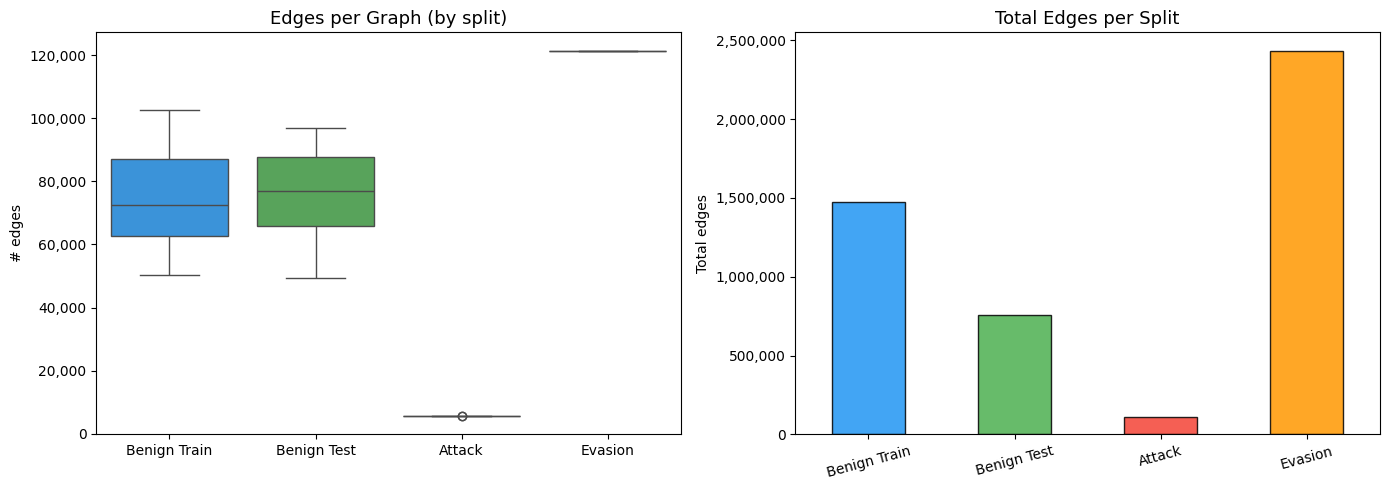

In [10]:
## ---- 4a. Edges per graph — boxplot across splits ----
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Left: distribution of edges-per-graph
all_graph_edges = []
for df_, lbl in [(df_train,'Benign Train'),(df_test,'Benign Test'),(df_attack,'Attack')] + \
                ([(df_evasion,'Evasion')] if not df_evasion.empty else []):
    for n_edges in df_.groupby('graphFile').size().values:
        all_graph_edges.append({'label': lbl, 'edges': n_edges})
edge_df = pd.DataFrame(all_graph_edges)

order = ['Benign Train','Benign Test','Attack','Evasion']
order = [o for o in order if o in edge_df['label'].unique()]
palette = {'Benign Train':'#2196F3','Benign Test':'#4CAF50','Attack':'#F44336','Evasion':'#FF9800'}
sns.boxplot(data=edge_df, x='label', y='edges', order=order, palette=palette, ax=axes[0])
axes[0].set_title('Edges per Graph (by split)', fontsize=13)
axes[0].set_xlabel('')
axes[0].set_ylabel('# edges')
axes[0].yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{int(x):,}'))

# Right: total edges per split (bar)
totals = edge_df.groupby('label')['edges'].sum().reindex(order)
colors = [palette[l] for l in totals.index]
totals.plot(kind='bar', ax=axes[1], color=colors, edgecolor='black', alpha=0.85)
axes[1].set_title('Total Edges per Split', fontsize=13)
axes[1].set_xlabel('')
axes[1].set_ylabel('Total edges')
axes[1].yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{int(x):,}'))
axes[1].tick_params(axis='x', rotation=15)

plt.tight_layout()
plt.savefig(BASE / 'plot_edge_distribution.png', dpi=120, bbox_inches='tight')
plt.show()

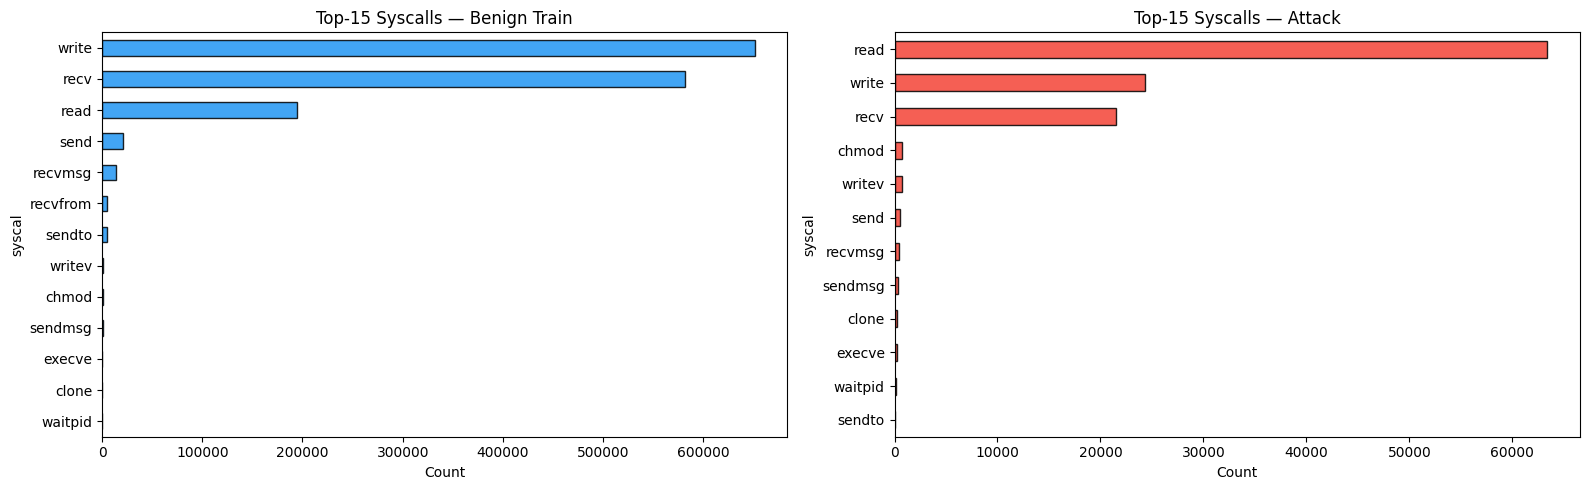

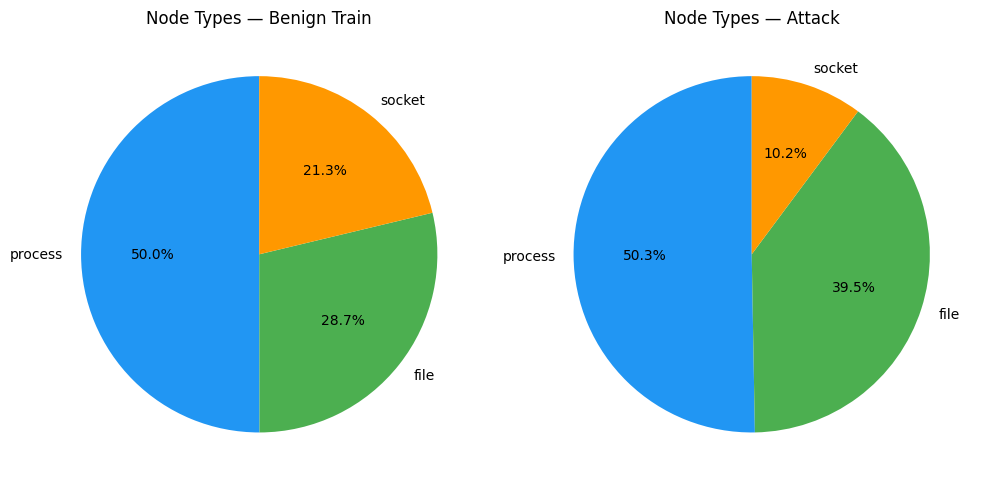

In [11]:
## ---- 4b. Syscall distribution: benign vs attack ----
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

for ax, (df_, lbl, color) in zip(axes, [(df_train,'Benign Train','#2196F3'),(df_attack,'Attack','#F44336')]):
    top = df_['syscal'].str.strip().value_counts().head(15)
    top.plot(kind='barh', ax=ax, color=color, alpha=0.85, edgecolor='black')
    ax.set_title(f'Top-15 Syscalls — {lbl}', fontsize=12)
    ax.set_xlabel('Count')
    ax.invert_yaxis()

plt.tight_layout()
plt.savefig(BASE / 'plot_syscall_dist.png', dpi=120, bbox_inches='tight')
plt.show()

## ---- 4c. Node type pie charts ----
fig, axes = plt.subplots(1, 2, figsize=(10, 5))
for ax, (df_, lbl) in zip(axes, [(df_train,'Benign Train'),(df_attack,'Attack')]):
    types = pd.concat([
        df_['sourceType'].str.strip(),
        df_['destType'].str.strip()
    ]).value_counts()
    types.plot(kind='pie', ax=ax, autopct='%1.1f%%', startangle=90,
               colors=['#2196F3','#4CAF50','#FF9800','#9C27B0','#795548'])
    ax.set_title(f'Node Types — {lbl}')
    ax.set_ylabel('')

plt.tight_layout()
plt.savefig(BASE / 'plot_node_types.png', dpi=120, bbox_inches='tight')
plt.show()

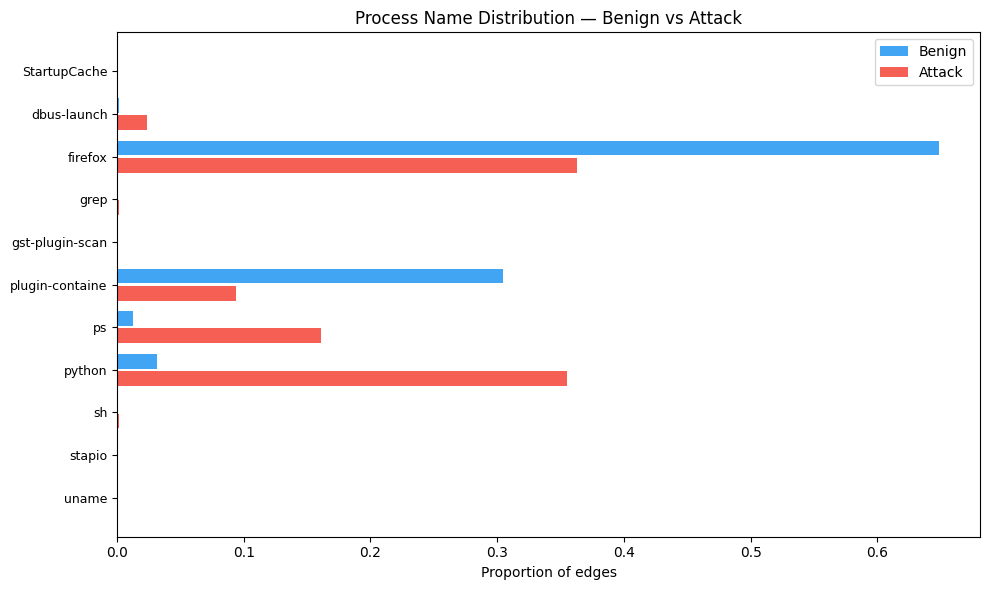

In [12]:
## ---- 4d. Top process names: benign vs attack (Diverging bar) ----
ben_procs = df_train['processName'].str.strip().value_counts().head(10)
att_procs = df_attack['processName'].str.strip().value_counts().head(10)

all_procs = sorted(set(ben_procs.index) | set(att_procs.index))
ben_vals  = [ben_procs.get(p, 0) for p in all_procs]
att_vals  = [att_procs.get(p, 0) for p in all_procs]

# Normalize
ben_norm = np.array(ben_vals) / (sum(ben_vals) or 1)
att_norm = np.array(att_vals) / (sum(att_vals) or 1)

fig, ax = plt.subplots(figsize=(10, 6))
y = np.arange(len(all_procs))
ax.barh(y - 0.2, ben_norm, height=0.35, color='#2196F3', label='Benign', alpha=0.85)
ax.barh(y + 0.2, att_norm, height=0.35, color='#F44336', label='Attack', alpha=0.85)
ax.set_yticks(y)
ax.set_yticklabels(all_procs, fontsize=9)
ax.set_xlabel('Proportion of edges')
ax.set_title('Process Name Distribution — Benign vs Attack', fontsize=12)
ax.legend()
ax.invert_yaxis()
plt.tight_layout()
plt.savefig(BASE / 'plot_process_names.png', dpi=120, bbox_inches='tight')
plt.show()

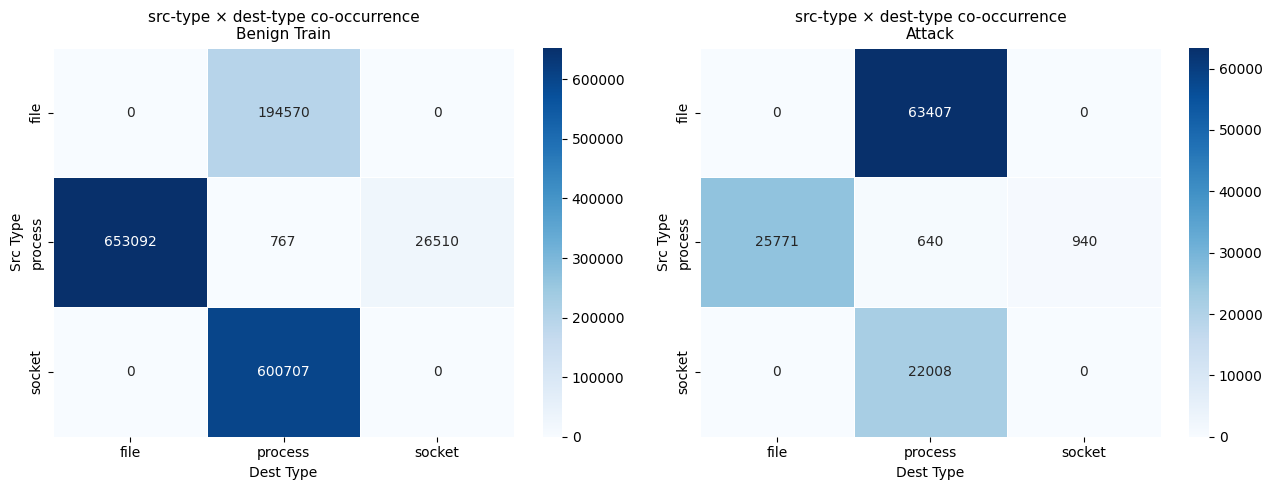

In [13]:
## ---- 4e. Syscall heatmap: srcType x destType co-occurrence ----
def cooc_matrix(df):
    df2 = df.copy()
    df2['srcT'] = df2['sourceType'].str.strip()
    df2['dstT'] = df2['destType'].str.strip()
    ct = pd.crosstab(df2['srcT'], df2['dstT'])
    return ct

fig, axes = plt.subplots(1, 2, figsize=(13, 5))
for ax, (df_, lbl) in zip(axes, [(df_train,'Benign Train'),(df_attack,'Attack')]):
    m = cooc_matrix(df_)
    sns.heatmap(m, annot=True, fmt='d', cmap='Blues', ax=ax, linewidths=0.5)
    ax.set_title(f'src-type × dest-type co-occurrence\n{lbl}', fontsize=11)
    ax.set_xlabel('Dest Type')
    ax.set_ylabel('Src Type')

plt.tight_layout()
plt.savefig(BASE / 'plot_cooc_heatmap.png', dpi=120, bbox_inches='tight')
plt.show()

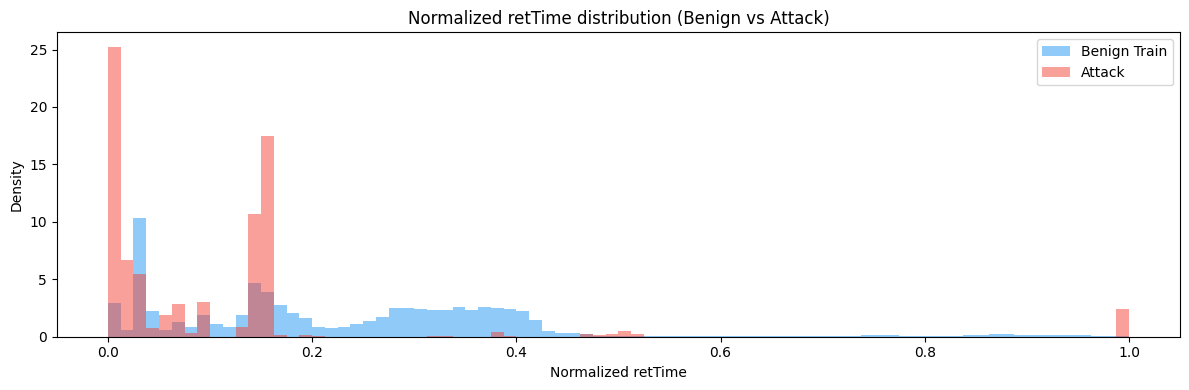

NOTE: Attack evasion injected edges have deliberately adjusted timestamps to blend in.


In [14]:
## ---- 4f. Timeline: retTime distribution per split ----
fig, ax = plt.subplots(figsize=(12, 4))
for df_, lbl, color in [(df_train,'Benign Train','#2196F3'),(df_attack,'Attack','#F44336')]:
    rt = pd.to_numeric(df_['retTime'], errors='coerce').dropna()
    rt_norm = (rt - rt.min()) / (rt.max() - rt.min() + 1e-9)
    ax.hist(rt_norm, bins=80, alpha=0.5, label=lbl, color=color, density=True)

ax.set_title('Normalized retTime distribution (Benign vs Attack)', fontsize=12)
ax.set_xlabel('Normalized retTime')
ax.set_ylabel('Density')
ax.legend()
plt.tight_layout()
plt.savefig(BASE / 'plot_rettime.png', dpi=120, bbox_inches='tight')
plt.show()
print("NOTE: Attack evasion injected edges have deliberately adjusted timestamps to blend in.")

## 5. Build FGA Input — Chuyển CSV → `.pth` Tensors

FGA cần 3 file:
- `X.pth` — Node feature matrix `[num_nodes, feat_dim]`
- `edges.pth` — `[2, num_edges]` (src_idx, dst_idx)
- `names.pth` — List of `(node_name, node_type, graphId)` cho mỗi node

Ta sẽ gộp tất cả train graphs + test graphs + attack graphs, encode node type (process=1, file=2, socket=3), đánh graphId theo thứ tự.

In [15]:
import torch

TYPE_MAP = {'process': 1.0, 'file': 2.0, 'socket': 3.0}
FEAT_DIM = 8   # one-hot-like 8-dim feature

def type_feature(t_str):
    """Node type → 8-dim feature vector."""
    t = t_str.strip().lower() if isinstance(t_str, str) else 'file'
    v = TYPE_MAP.get(t, 2.0)
    feat = torch.zeros(FEAT_DIM)
    feat[0] = v                  # raw type code
    feat[int(v)] = 1.0           # one-hot position 1/2/3
    return feat

def build_pth(file_list, graph_labels, save_dir, max_files=None):
    """
    Build X.pth, edges.pth, names.pth from a list of (csv_path, graph_label) pairs.
    graph_labels: dict {filename: (graphId, split_label)}
    Returns counts for reporting.
    """
    save_dir = Path(save_dir)
    save_dir.mkdir(parents=True, exist_ok=True)

    node2idx = {}   # (nodeName, nodeType, graphId) -> global index
    names    = []   # list of (nodeName, nodeType, graphId)
    X_rows   = []   # feature per node
    src_list = []
    dst_list = []

    if max_files:
        file_list = file_list[:max_files]

    for csv_path, gid in file_list:
        try:
            df = pd.read_csv(csv_path, names=COLS, on_bad_lines='skip', low_memory=False)
        except Exception as e:
            print(f"  skip {csv_path}: {e}")
            continue

        for _, row in df.iterrows():
            src_name = str(row['sourceId']).strip().strip('"')
            src_type = str(row['sourceType']).strip()
            dst_name = str(row['destId']).strip().strip('"')
            dst_type = str(row['destType']).strip()

            src_key = (src_name, src_type, gid)
            dst_key = (dst_name, dst_type, gid)

            if src_key not in node2idx:
                node2idx[src_key] = len(names)
                names.append(src_key)
                X_rows.append(type_feature(src_type))

            if dst_key not in node2idx:
                node2idx[dst_key] = len(names)
                names.append(dst_key)
                X_rows.append(type_feature(dst_type))

            src_list.append(node2idx[src_key])
            dst_list.append(node2idx[dst_key])

    X      = torch.stack(X_rows)                              # [N, FEAT_DIM]
    edges  = torch.tensor([src_list, dst_list], dtype=torch.long)  # [2, E]

    torch.save(X,     save_dir / 'X.pth')
    torch.save(edges, save_dir / 'edges.pth')
    torch.save(names, save_dir / 'names.pth')

    print(f"  Saved → {save_dir.name}/  |  nodes={X.shape[0]:,}  edges={edges.shape[1]:,}  graphs={len(file_list)}")
    return X, edges, names


# --- Build training set (benign only, first 20 graphs) ---
PTH_DIR = BASE / 'FGA' / 'pth_data'

train_files = sorted(TRAIN_DIR.glob('*.csv'))
test_files  = sorted(TEST_DIR.glob('*.csv'))
att_files   = sorted(ATTACK_DIR.glob('*.csv'))
ev_files    = sorted(EVASION_DIR.glob('*.csv')) if EVASION_DIR.exists() else []

MAX_TRAIN = 15
MAX_TEST  = 10
MAX_ATT   = 15
MAX_EV    = 15

# Build & assign graphIds sequentially
def make_file_list(files, start_id, max_n=None):
    files = files[:max_n] if max_n else files
    return [(str(f), start_id + i) for i, f in enumerate(files)]

train_list = make_file_list(train_files, 0,       MAX_TRAIN)
test_list  = make_file_list(test_files,  MAX_TRAIN, MAX_TEST)
att_list   = make_file_list(att_files,   MAX_TRAIN+MAX_TEST, MAX_ATT)
ev_list    = make_file_list(ev_files,    MAX_TRAIN+MAX_TEST+MAX_ATT, MAX_EV)

print("Building train .pth ...")
X_train, E_train, N_train = build_pth(train_list,  {}, PTH_DIR / 'train', MAX_TRAIN)

print("Building test+attack+evasion .pth ...")
all_test = test_list + att_list + (ev_list if ev_list else [])
X_test, E_test, N_test = build_pth(all_test, {}, PTH_DIR / 'test', len(all_test))

print("Done.")

Building train .pth ...
  Saved → train/  |  nodes=21,379  edges=1,150,385  graphs=15
Building test+attack+evasion .pth ...
  Saved → test/  |  nodes=53,239  edges=2,662,963  graphs=40
Done.


## 6. Train FGA — ARGVA Graph Autoencoder

**ARGVA** = Adversarially Regularized Graph Variational Autoencoder  
- **Encoder**: GCN 2-layer → mean/logstd → reparametrize → latent `z`  
- **Discriminator**: MLP để "ép" `z` gần distribution chuẩn (adversarial)  
- **Loss**: reconstruction + KL + adversarial  
- **Output mỗi graph**: vector embedding trung bình `z_mean` → dùng `cdist` để so sánh với training embeddings

In [16]:
import torch
import torch.nn as nn
from torch.nn import Linear
from torch_geometric.nn import GCNConv, ARGVA
from torch_geometric.utils import to_undirected

# ── Model Architecture ──────────────────────────────────────────────────────
class Encoder(nn.Module):
    def __init__(self, in_ch, hidden, out_ch):
        super().__init__()
        self.conv1    = GCNConv(in_ch, hidden)
        self.conv_mu  = GCNConv(hidden, out_ch)
        self.conv_std = GCNConv(hidden, out_ch)

    def forward(self, x, edge_index):
        x = self.conv1(x, edge_index).relu()
        return self.conv_mu(x, edge_index), self.conv_std(x, edge_index)


class Discriminator(nn.Module):
    def __init__(self, in_ch, hidden, out_ch):
        super().__init__()
        self.net = nn.Sequential(
            Linear(in_ch, hidden), nn.ReLU(),
            Linear(hidden, hidden), nn.ReLU(),
            Linear(hidden, out_ch)
        )
    def forward(self, x): return self.net(x)


# ── Hyperparams ──────────────────────────────────────────────────────────────
IN_CH    = FEAT_DIM
HIDDEN   = 32
LATENT   = 16
EPOCHS   = 300
LR_ENC   = 5e-4
LR_DISC  = 1e-4
DEVICE   = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
MODEL_PATH = BASE / 'FGA' / 'fga_trained.pth'

print(f"Device: {DEVICE}  |  In={IN_CH}  Hidden={HIDDEN}  Latent={LATENT}  Epochs={EPOCHS}")

Device: cuda  |  In=8  Hidden=32  Latent=16  Epochs=300


In [17]:
## ---- 6b. Training loop ----
x_tr = X_train.to(DEVICE)
e_tr = to_undirected(E_train).to(DEVICE)
num_nodes = x_tr.shape[0]

encoder       = Encoder(IN_CH, HIDDEN, LATENT)
discriminator = Discriminator(LATENT, HIDDEN, LATENT)
model         = ARGVA(encoder, discriminator).to(DEVICE)

enc_opt  = torch.optim.Adam(encoder.parameters(),       lr=LR_ENC)
disc_opt = torch.optim.Adam(discriminator.parameters(), lr=LR_DISC)

loss_history = []

if not MODEL_PATH.exists():
    print(f"Training ARGVA for {EPOCHS} epochs...")
    for epoch in range(1, EPOCHS + 1):
        model.train()

        # 1) Encoder step
        enc_opt.zero_grad()
        z = model.encode(x_tr, e_tr)
        # 2) Discriminator steps (×5)
        for _ in range(5):
            disc_opt.zero_grad()
            disc_loss = model.discriminator_loss(z)
            disc_loss.backward(retain_graph=True)
            disc_opt.step()
        # 3) Encoder loss
        loss = (model.recon_loss(z, e_tr)
                + model.reg_loss(z)
                + (1 / num_nodes) * model.kl_loss())
        loss.backward()
        enc_opt.step()

        loss_history.append(float(loss))
        if epoch % 50 == 0 or epoch == 1:
            print(f"  Epoch {epoch:4d}/{EPOCHS}  loss={float(loss):.4f}")

    torch.save({'model': model.state_dict(), 'loss': loss_history}, MODEL_PATH)
    print(f"\nModel saved → {MODEL_PATH}")
else:
    print(f"Loading existing model from {MODEL_PATH}")
    ckpt = torch.load(MODEL_PATH, map_location=DEVICE)
    model.load_state_dict(ckpt['model'])
    loss_history = ckpt.get('loss', [])
    print(f"  Loaded. Loss history length: {len(loss_history)}")

Training ARGVA for 300 epochs...
  Epoch    1/300  loss=19.3493
  Epoch   50/300  loss=4.5263
  Epoch  100/300  loss=3.0310
  Epoch  150/300  loss=2.6570
  Epoch  200/300  loss=2.5078
  Epoch  250/300  loss=2.4798
  Epoch  300/300  loss=2.5771

Model saved → c:\Users\PC\Desktop\mimicry-provenance-generator\FGA\fga_trained.pth


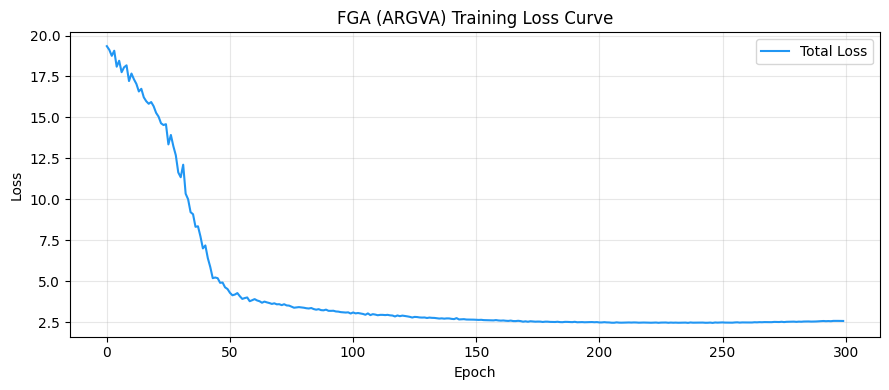

Final loss: 2.5771


In [18]:
## ---- 6c. Plot training loss ----
if loss_history:
    fig, ax = plt.subplots(figsize=(9, 4))
    ax.plot(loss_history, color='#2196F3', linewidth=1.5, label='Total Loss')
    ax.set_xlabel('Epoch')
    ax.set_ylabel('Loss')
    ax.set_title('FGA (ARGVA) Training Loss Curve')
    ax.legend()
    ax.grid(alpha=0.3)
    plt.tight_layout()
    plt.savefig(BASE / 'plot_loss_curve.png', dpi=120, bbox_inches='tight')
    plt.show()
    print(f"Final loss: {loss_history[-1]:.4f}")

## 7. Đánh giá kết quả

**Pipeline đánh giá:**
1. Encode mỗi graph (train/test/attack/evasion) → graph embedding `z_mean`
2. Anomaly score = `min_distance(z_test, z_train_set)` — dùng `cdist`
3. Benign graph → score thấp; Attack/Evasion → score cao
4. Tính ROC-AUC, vẽ distribution, confusion matrix

In [19]:
## ---- 7a. Embed each graph individually ----
from torch_geometric.utils import to_undirected

def embed_graph_list(file_list, model, device, names_ref=None):
    """
    Encode each graph in file_list separately.
    Returns list of (embedding_vector, graphId, split_label).
    """
    model.eval()
    results = []
    for (csv_path, gid) in file_list:
        try:
            df = pd.read_csv(csv_path, names=COLS, on_bad_lines='skip', low_memory=False)
        except:
            continue
        # Build local node index for this single graph
        local_node2idx = {}
        local_names    = []
        local_X        = []
        src_l, dst_l   = [], []

        for _, row in df.iterrows():
            sn = str(row['sourceId']).strip().strip('"')
            st = str(row['sourceType']).strip()
            dn = str(row['destId']).strip().strip('"')
            dt = str(row['destType']).strip()

            for key, typ in [((sn, st), st), ((dn, dt), dt)]:
                if key not in local_node2idx:
                    local_node2idx[key] = len(local_names)
                    local_names.append(key)
                    local_X.append(type_feature(typ))

            src_l.append(local_node2idx[(sn, st)])
            dst_l.append(local_node2idx[(dn, dt)])

        if not src_l:
            continue

        X_g = torch.stack(local_X).to(device)
        E_g = to_undirected(torch.tensor([src_l, dst_l], dtype=torch.long)).to(device)

        with torch.no_grad():
            z = model.encode(X_g, E_g)          # [N, LATENT]
            g_embed = z.mean(dim=0).cpu()        # mean pooling → [LATENT]

        results.append((g_embed, gid))
    return results

print("Embedding TRAIN graphs ...")
train_embeds = embed_graph_list(train_list, model, DEVICE)
print(f"  {len(train_embeds)} train embeddings")

print("Embedding TEST (benign) graphs ...")
test_embeds  = embed_graph_list(test_list, model, DEVICE)
print(f"  {len(test_embeds)} test embeddings")

print("Embedding ATTACK graphs ...")
att_embeds   = embed_graph_list(att_list, model, DEVICE)
print(f"  {len(att_embeds)} attack embeddings")

print("Embedding EVASION graphs ...")
ev_embeds    = embed_graph_list(ev_list,  model, DEVICE) if ev_list else []
print(f"  {len(ev_embeds)} evasion embeddings")

Embedding TRAIN graphs ...
  15 train embeddings
Embedding TEST (benign) graphs ...
  10 test embeddings
Embedding ATTACK graphs ...
  15 attack embeddings
Embedding EVASION graphs ...
  15 evasion embeddings


In [20]:
## ---- 7b. Compute anomaly scores (min-cdist to training set) ----
train_mat = torch.stack([e[0] for e in train_embeds])  # [N_train, LATENT]

def anomaly_scores(embeds, train_mat):
    """Minimum distance to any training embedding = anomaly score."""
    if not embeds:
        return np.array([])
    test_mat = torch.stack([e[0] for e in embeds])      # [N_test, LATENT]
    dists = torch.cdist(test_mat, train_mat)             # [N_test, N_train]
    scores = dists.min(dim=1).values.numpy()
    return scores

scores_train   = anomaly_scores(train_embeds, train_mat)
scores_test    = anomaly_scores(test_embeds,  train_mat)
scores_attack  = anomaly_scores(att_embeds,   train_mat)
scores_evasion = anomaly_scores(ev_embeds,    train_mat)

print("Anomaly score statistics:")
for name, sc in [('Train(ben)', scores_train),('Test(ben)',scores_test),
                 ('Attack',scores_attack),('Evasion',scores_evasion)]:
    if len(sc):
        print(f"  {name:12s}: mean={sc.mean():.4f}  std={sc.std():.4f}  min={sc.min():.4f}  max={sc.max():.4f}")

Anomaly score statistics:
  Train(ben)  : mean=0.0000  std=0.0000  min=0.0000  max=0.0000
  Test(ben)   : mean=0.0005  std=0.0004  min=0.0000  max=0.0012
  Attack      : mean=0.0365  std=0.0000  min=0.0365  max=0.0365
  Evasion     : mean=0.0002  std=0.0000  min=0.0002  max=0.0002


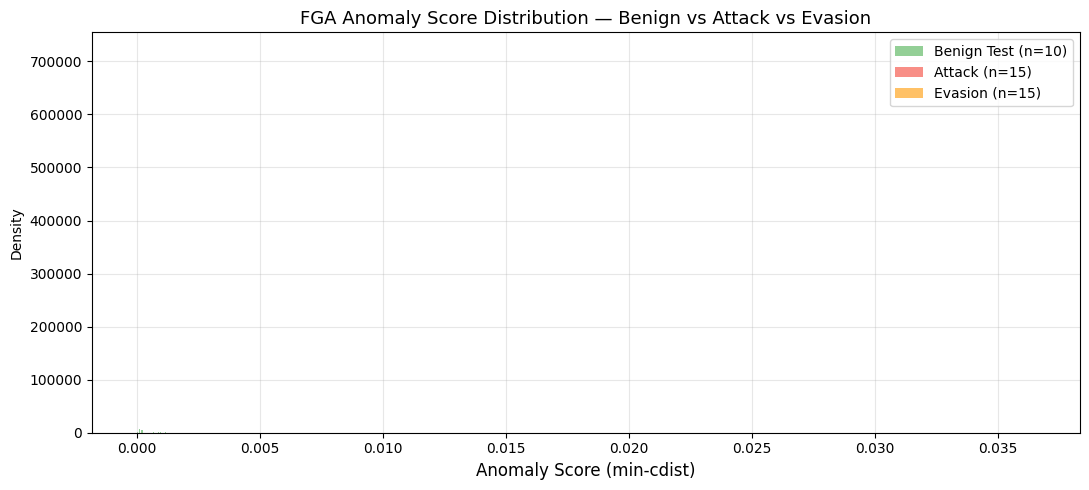

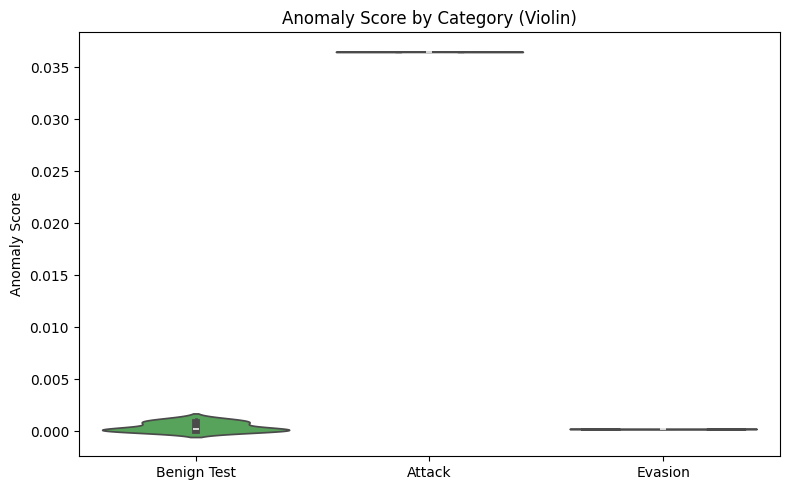

In [21]:
## ---- 7c. Score distribution plot ----
fig, ax = plt.subplots(figsize=(11, 5))
plot_data = [
    ('Benign Test',  scores_test,    '#4CAF50'),
    ('Attack',       scores_attack,  '#F44336'),
]
if len(scores_evasion): plot_data.append(('Evasion', scores_evasion, '#FF9800'))

for label, sc, color in plot_data:
    if len(sc):
        ax.hist(sc, bins=25, alpha=0.6, color=color, label=f'{label} (n={len(sc)})', density=True)

ax.set_xlabel('Anomaly Score (min-cdist)', fontsize=12)
ax.set_ylabel('Density')
ax.set_title('FGA Anomaly Score Distribution — Benign vs Attack vs Evasion', fontsize=13)
ax.legend(fontsize=10)
ax.grid(alpha=0.3)
plt.tight_layout()
plt.savefig(BASE / 'plot_score_dist.png', dpi=120, bbox_inches='tight')
plt.show()

# Violin plot
all_scores = []
for label, sc, color in plot_data:
    for s in sc:
        all_scores.append({'label': label, 'score': s})
score_df = pd.DataFrame(all_scores)
fig, ax = plt.subplots(figsize=(8, 5))
sns.violinplot(data=score_df, x='label', y='score',
               palette={'Benign Test':'#4CAF50','Attack':'#F44336','Evasion':'#FF9800'},
               ax=ax, inner='box')
ax.set_title('Anomaly Score by Category (Violin)', fontsize=12)
ax.set_xlabel('')
ax.set_ylabel('Anomaly Score')
plt.tight_layout()
plt.savefig(BASE / 'plot_score_violin.png', dpi=120, bbox_inches='tight')
plt.show()

Attack: ROC-AUC=1.0000  AP=1.0000
Evasion: ROC-AUC=0.5533  AP=0.5888


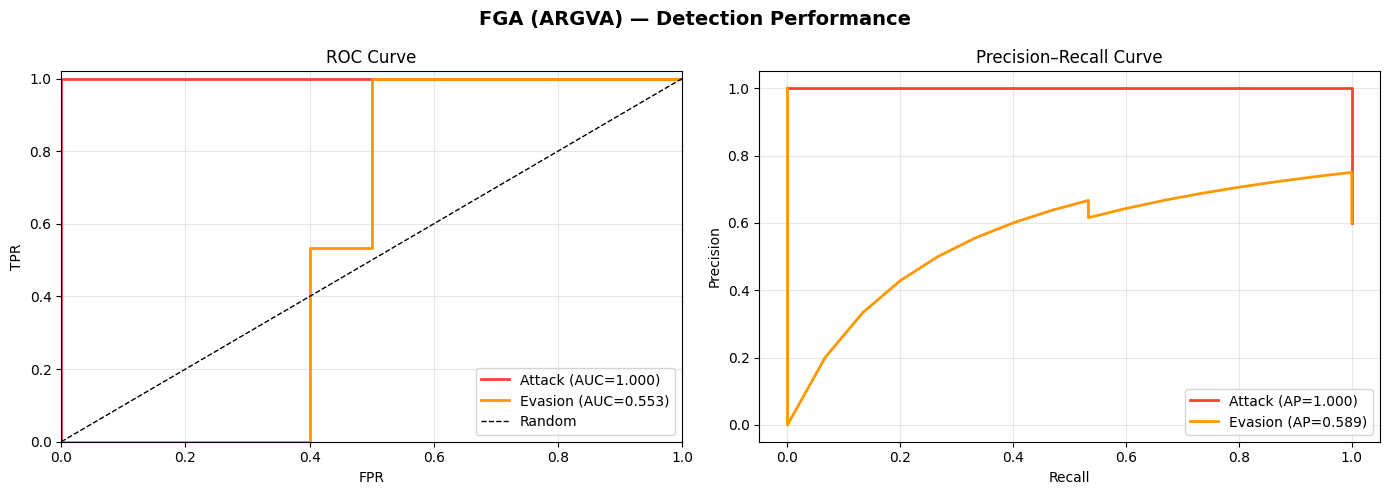

In [22]:
## ---- 7d. ROC Curve & AUC ----
from sklearn.metrics import roc_curve, auc, precision_recall_curve, average_precision_score

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for ax_idx, (threat_name, threat_scores, color) in enumerate([
    ('Attack',  scores_attack,  '#F44336'),
    ('Evasion', scores_evasion, '#FF9800'),
]):
    if not len(threat_scores):
        continue

    ben_scores = scores_test if len(scores_test) else scores_train
    y_true = np.array([0]*len(ben_scores) + [1]*len(threat_scores))
    y_score= np.concatenate([ben_scores, threat_scores])

    # ROC
    fpr, tpr, thresholds = roc_curve(y_true, y_score)
    roc_auc = auc(fpr, tpr)

    ax = axes[0]
    ax.plot(fpr, tpr, color=color, lw=2, label=f'{threat_name} (AUC={roc_auc:.3f})')

    # Precision-Recall
    prec, rec, _ = precision_recall_curve(y_true, y_score)
    ap = average_precision_score(y_true, y_score)
    axes[1].plot(rec, prec, color=color, lw=2, label=f'{threat_name} (AP={ap:.3f})')

    print(f"{threat_name}: ROC-AUC={roc_auc:.4f}  AP={ap:.4f}")

axes[0].plot([0,1],[0,1],'k--', lw=1, label='Random')
axes[0].set_title('ROC Curve', fontsize=12)
axes[0].set_xlabel('FPR'); axes[0].set_ylabel('TPR')
axes[0].legend(); axes[0].grid(alpha=0.3)
axes[0].set_xlim([0,1]); axes[0].set_ylim([0,1.02])

axes[1].set_title('Precision–Recall Curve', fontsize=12)
axes[1].set_xlabel('Recall'); axes[1].set_ylabel('Precision')
axes[1].legend(); axes[1].grid(alpha=0.3)

plt.suptitle('FGA (ARGVA) — Detection Performance', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig(BASE / 'plot_roc_pr.png', dpi=120, bbox_inches='tight')
plt.show()


Attack @ threshold=0.0365
              precision    recall  f1-score   support

      Benign       1.00      1.00      1.00        10
      Threat       1.00      1.00      1.00        15

    accuracy                           1.00        25
   macro avg       1.00      1.00      1.00        25
weighted avg       1.00      1.00      1.00        25


Evasion @ threshold=0.0002
              precision    recall  f1-score   support

      Benign       1.00      0.50      0.67        10
      Threat       0.75      1.00      0.86        15

    accuracy                           0.80        25
   macro avg       0.88      0.75      0.76        25
weighted avg       0.85      0.80      0.78        25



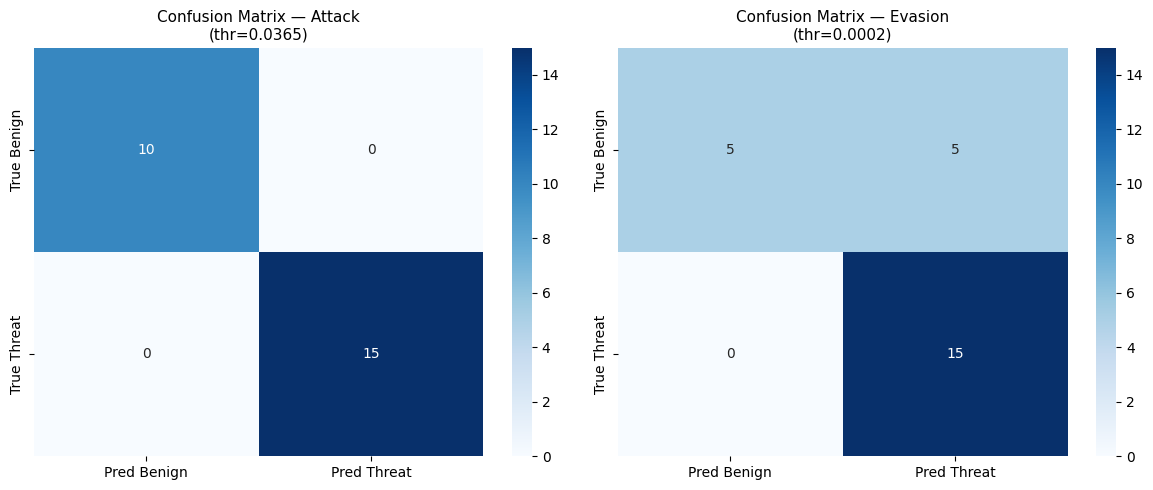

In [23]:
## ---- 7e. Confusion matrix at best threshold ----
from sklearn.metrics import confusion_matrix, classification_report

def best_threshold_cm(ben_sc, thr_sc, threat_name):
    y_true  = np.array([0]*len(ben_sc) + [1]*len(thr_sc))
    y_score = np.concatenate([ben_sc, thr_sc])
    # Youden's J statistic
    fpr, tpr, thresholds = roc_curve(y_true, y_score)
    j_scores = tpr - fpr
    best_thr = thresholds[np.argmax(j_scores)]
    y_pred   = (y_score >= best_thr).astype(int)
    cm = confusion_matrix(y_true, y_pred)
    print(f"\n{'='*50}")
    print(f"{threat_name} @ threshold={best_thr:.4f}")
    print(f"{'='*50}")
    print(classification_report(y_true, y_pred, target_names=['Benign','Threat']))
    return cm, best_thr

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

for ax, (threat_nm, threat_sc, color) in zip(axes,[
    ('Attack',  scores_attack,  '#F44336'),
    ('Evasion', scores_evasion, '#FF9800'),
]):
    if not len(threat_sc):
        ax.axis('off'); continue
    ben_sc = scores_test if len(scores_test) else scores_train
    cm, thr = best_threshold_cm(ben_sc, threat_sc, threat_nm)
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=ax,
                xticklabels=['Pred Benign','Pred Threat'],
                yticklabels=['True Benign','True Threat'])
    ax.set_title(f'Confusion Matrix — {threat_nm}\n(thr={thr:.4f})', fontsize=11)

plt.tight_layout()
plt.savefig(BASE / 'plot_confusion_matrix.png', dpi=120, bbox_inches='tight')
plt.show()

In [24]:
## ---- 7f. Evasion rate (how many attacks BYPASS FGA) ----
def evasion_rate(ben_sc, thr_sc):
    """% of attack/evasion graphs with score BELOW the benign 99th percentile threshold."""
    if not len(thr_sc): return None
    thr = np.percentile(ben_sc, 99)   # 99th pct of benign = "safe" boundary
    bypassed = (thr_sc < thr).sum()
    total    = len(thr_sc)
    return bypassed / total * 100, thr

ben_ref = scores_test if len(scores_test) else scores_train

print("="*55)
print("    FINAL RESULTS SUMMARY")
print("="*55)

for name, sc in [('Attack', scores_attack), ('Evasion', scores_evasion)]:
    if not len(sc): continue
    ev, thr = evasion_rate(ben_ref, sc)
    y_true  = np.array([0]*len(ben_ref) + [1]*len(sc))
    y_score_all = np.concatenate([ben_ref, sc])
    fpr_arr, tpr_arr, _ = roc_curve(y_true, y_score_all)
    roc_auc = auc(fpr_arr, tpr_arr)
    detected = (sc >= thr).sum()
    print(f"  {name:10s}: ROC-AUC={roc_auc:.4f}  |  Detected={detected}/{len(sc)} ({100-ev:.1f}%)  |  Evasion Rate={ev:.1f}%")

print("="*55)
print("\nKey insight:")
print("  Evasion Rate = % of attacks the IDS MISSES (lower = IDS is stronger)")
print("  ROC-AUC     = overall discrimination ability (1.0 = perfect)")
print("\nPlots saved: plot_*.png")

    FINAL RESULTS SUMMARY
  Attack    : ROC-AUC=1.0000  |  Detected=15/15 (100.0%)  |  Evasion Rate=0.0%
  Evasion   : ROC-AUC=0.5533  |  Detected=0/15 (0.0%)  |  Evasion Rate=100.0%

Key insight:
  Evasion Rate = % of attacks the IDS MISSES (lower = IDS is stronger)
  ROC-AUC     = overall discrimination ability (1.0 = perfect)

Plots saved: plot_*.png
